In [25]:
import numpy as np
from matplotlib import pyplot as plt
import healpy as hp
import time

import warnings
warnings.filterwarnings('ignore')

start = time.time()

In [6]:
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #
# LiteBIRD's IMO
import json
# opening IMO schema.json file and interpreting it as a dictionary
f = open('/global/u2/m/martam/LB_validation/schema.json',)
data = json.load(f)  

# looking into the IMO, data['data_files'] is where the relevant info is stored
data_files = data['data_files']

# counting how many objects are in data_files
nkey=0
for key in data_files:
    nkey = nkey+1
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

In [9]:
#healpy resolution, definition of ell arrays
nside = 512
lmax = 2*nside-1
ell = np.arange(lmax+1)
npix = hp.nside2npix(nside)

In [10]:
#input maps' paths (post-PTEP)
path_cmb = '/global/cfs/cdirs/litebird/simulations/maps/post_ptep_inputs_20220522/beam_convolved/cmb/'
path_fgs = '/global/cfs/cdirs/litebird/simulations/maps/post_ptep_inputs_20220522/beam_convolved/all_fg/'
path_coadd = '/global/cfs/cdirs/litebird/simulations/maps/post_ptep_inputs_20220522/beam_convolved/coadded/'

In [12]:
#correspondence between input and output channels
n_chan = 17
chan_dicts = np.array([{'instr':'HFT' , 'sim':'HFT_195' , 'IMO':'H1-195'},
                       {'instr':'HFT' , 'sim':'HFT_280' , 'IMO':'H1-280'},
                       {'instr':'HFT' , 'sim':'HFT_337' , 'IMO':'H2-337'},
                       {'instr':'HFT' , 'sim':'HFT_402' , 'IMO':'H3-402'},
                       {'instr':'HFT' , 'sim':'LFT_40'  , 'IMO':'L1-040'},
                       {'instr':'LFT' , 'sim':'LFT_60'  , 'IMO':'L1-060'},
                       {'instr':'LFT' , 'sim':'LFT_78a' , 'IMO':'L1-078'},
                       {'instr':'LFT' , 'sim':'LFT_50'  , 'IMO':'L2-050'},
                       {'instr':'LFT' , 'sim':'LFT_60'  , 'IMO':'L1-060'},
                       {'instr':'LFT' , 'sim':'LFT_68a' , 'IMO':'L2-068'},
                       {'instr':'LFT' , 'sim':'LFT_89a' , 'IMO':'L2-089'},
                       {'instr':'LFT' , 'sim':'LFT_68b' , 'IMO':'L3-068'},
                       {'instr':'LFT' , 'sim':'LFT_89b' , 'IMO':'L3-089'},
                       {'instr':'LFT' , 'sim':'LFT_119' , 'IMO':'L3-119'},
                       {'instr':'LFT' , 'sim':'LFT_78b' , 'IMO':'L4-078'},
                       {'instr':'LFT' , 'sim':'LFT_100' , 'IMO':'L4-100'},
                       {'instr':'LFT' , 'sim':'LFT_140' , 'IMO':'L4-140'}])

MC_sim = '00'

#for i in np.array([7]): #can be made into a for loop
i = 7

instrument_name = chan_dicts[i]['instr']
channel_sim = chan_dicts[i]['sim']
channel_IMO = chan_dicts[i]['IMO']

In [13]:
#output maps' path
path_out = '/global/cscratch1/sd/bortolam/litebird/e2e_ns512/sim0000/detectors_'+instrument_name+'_'+channel_IMO+'_T+B/'

In [19]:
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #
# looking for the detectors belonging to the selected channel
for j in range(nkey):
    test = data_files[j]
    if(test['name'] == 'channel_info'):
        metadata = test['metadata']
        if(metadata['channel'] == channel_IMO):
            pol_sensitivity_channel = metadata['pol_sensitivity_channel_ukarcmin']
            net_channel = metadata['net_channel_ukrts']
            detector_names = metadata['detector_names']
            break

ndet = len(detector_names)
det_indices = range(ndet)

In [15]:
list_of_dictionaries = []

# looking for the metadata of the detectors in detector_names
for d in detector_names:
    for j in range(nkey):
        test = data_files[j]
        if(test['name'] == 'detector_info'):
            metadata = test['metadata']
            if (metadata['name'] == d):
                list_of_dictionaries.append(metadata) # this list contains all the info about the M1-140 detectors
                break

In [21]:
# the following quantities are actually identical for each detector
fwhm = list_of_dictionaries[0]['fwhm_arcmin']
sampling_freq = list_of_dictionaries[0]['sampling_rate_hz']
alpha = list_of_dictionaries[0]['alpha']

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

In [23]:
print('fwhm: '+str(fwhm))
print('ndet: '+str(ndet))

fwhm: 58.5
ndet: 24


In [26]:
net_scaled = np.genfromtxt('/global/u2/m/martam/e2e-simulation/ancillary/detectors_'+instrument_name+'_'+channel_IMO+'_T+B.txt')[1, 4]
pixel_area = hp.nside2pixarea(nside)
maps_hits =  hp.read_map(path_out + 'madam_cmb_fg_wn_1f_30mHz/maps/hits.fits', field=None)
nhits = np.mean(maps_hits[0])

Nl_white_scaled = (net_scaled/np.sqrt(nhits/sampling_freq))**2*pixel_area*np.exp(ell*(ell+1)*np.radians(fwhm/60)**2/(8*np.log(2))) #Andrea Zonca's formula

In [27]:
blms = hp.sphtfunc.gauss_beam(np.radians(fwhm/60), lmax=lmax, pol=True)
blmT = blms[:,0]
blmE = blms[:,1]
blmB = blms[:,2]

beam = np.empty((6,len(ell)))

beam[0] = blmT**2
beam[1] = blmE**2
beam[2] = blmB**2
beam[3] = blmT*blmE
beam[4] = blmE*blmB
beam[5] = blmT*blmB

In [28]:
channel_in = channel_sim
channel_out = channel_sim

#updated paths for input and output
path_cmb_ij = path_cmb + MC_sim + '/'
path_coadd_ij = path_coadd + MC_sim + '/'

In [30]:
#input and output maps
maps_cmb = hp.read_map(path_cmb_ij + 'LB_' + channel_in + '_lens_cmb_postPTEP20220609.fits', field=None) 
maps_fgs = hp.read_map(path_fgs + 'LB_' + channel_in + '_all_fg_postPTEP20220609.fits', field=None) 
maps_coadd = hp.read_map(path_coadd_ij + 'LB_' + channel_in + '_coadd_signal_postPTEP20220609.fits', field=None) 
#
maps_cmb_fg_wn =  hp.read_map(path_out + 'maps/LB_' + channel_out + '_binned_cmb_fg_wn_365d_0000.fits', field=None)*10**6
maps_wn_1f_30mHz =  hp.read_map(path_out + 'maps/LB_' + channel_out + '_binned_wn_1f_30mHz_365d_0000.fits', field=None)*10**6
maps_wn_1f_100mHz = hp.read_map(path_out + 'maps/LB_' + channel_out + '_binned_wn_1f_100mHz_365d_0000.fits', field=None)*10**6
#
#maps_wn_1f_30mHz_binned =  hp.read_map(path_out + 'madam_wn_1f_30mHz/maps/binned.fits', field=None)*10**6 
#maps_wn_1f_100mHz_binned =  hp.read_map(path_out + 'madam_wn_1f_30mHz/maps/binned.fits', field=None)*10**6
#
#maps_cmb_fg_wn_1f_30mHz_destriped =  hp.read_map(path_out + 'madam_cmb_fg_wn_1f_30mHz/maps/destriped.fits', field=None)*10**6
#maps_cmb_fg_wn_1f_100mHz_destriped =  hp.read_map(path_out + 'madam_cmb_fg_wn_1f_100mHz/maps/destriped.fits', field=None)*10**6
#maps_wn_1f_30mHz_destriped =  hp.read_map(path_out + 'madam_wn_1f_30mHz/maps/destriped.fits', field=None)*10**6
#maps_wn_1f_100mHz_destriped =  hp.read_map(path_out + 'madam_wn_1f_100mHz/maps/destriped.fits', field=None)*10**6
#

In [31]:
present = time.time()-start
print(str(i+1) + 'th map read ' + str(present) + ' seconds in')

8th map read 31.0521080493927 seconds in


In [32]:
#evaluating all angular power spectra
Cl_cmb = hp.anafast(maps_cmb,lmax=lmax)
Cl_fgs = hp.anafast(maps_fgs,lmax=lmax)
Cl_coadd = hp.anafast(maps_coadd,lmax=lmax)

Cl_cmb_fg_wn = hp.anafast(maps_cmb_fg_wn,lmax=lmax)
Cl_wn_1f_30mHz = hp.anafast(maps_wn_1f_30mHz,lmax=lmax)
Cl_wn_1f_100mHz = hp.anafast(maps_wn_1f_100mHz,lmax=lmax)

#Cl_wn_1f_30mHz_destriped = hp.anafast(maps_wn_1f_30mHz_destriped,lmax=lmax)
#Cl_wn_1f_100mHz_binned = hp.anafast(maps_wn_1f_100mHz_binned,lmax=lmax)

Cl_wn_diff = hp.anafast(maps_cmb_fg_wn-maps_coadd,lmax=lmax)/beam

In [33]:
#deconvolving the spectra
Cl_cmb /= beam
Cl_fgs /= beam
Cl_coadd /= beam
Cl_cmb_fg_wn /= beam
Cl_wn_1f_30mHz /= beam
Cl_wn_1f_100mHz /= beam

In [34]:
present = time.time()-start
print(str(i+1) + 'th Cls computed ' + str(present) + ' seconds in')

8th Cls computed 78.1841311454773 seconds in


In [35]:
present = time.time()-start
print('started plotting ' + str(present) + ' seconds in')

started plotting 156.4528350830078 seconds in


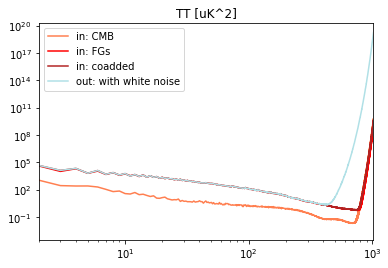

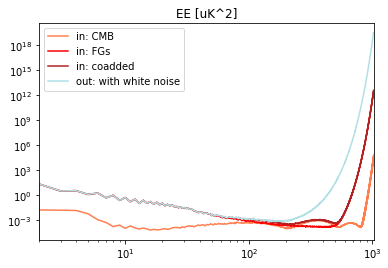

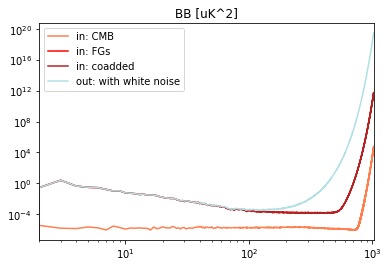

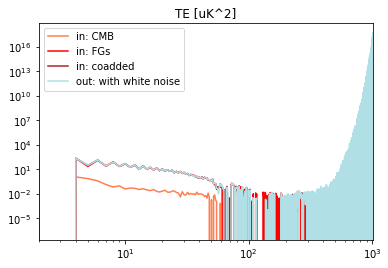

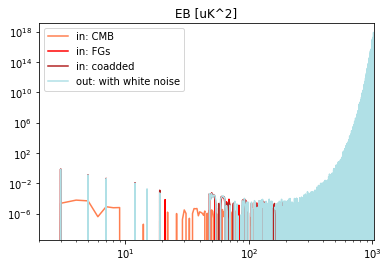

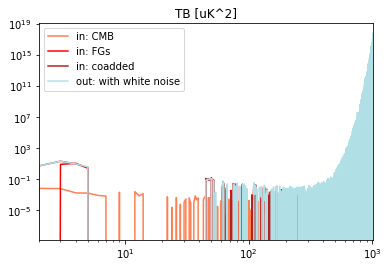

In [37]:
#plot all six loglog spectra
arr = np.array(['TT','EE','BB','TE','EB','TB'])
for j in np.arange(6):
    plt.loglog(Cl_cmb[j], color='coral', label='in: CMB')
    plt.loglog(Cl_fgs[j], color='red', label='in: FGs')
    plt.loglog(Cl_coadd[j], color='firebrick', label='in: coadded')
    plt.loglog(Cl_cmb_fg_wn[j], color='powderblue', label='out: with white noise')
    plt.title(arr[j]+' [uK^2]')
    plt.xlim([2,lmax])
    plt.legend()
    plt.show()
    #plt.savefig(arr[j]+'_loglog.pdf')
    plt.close()


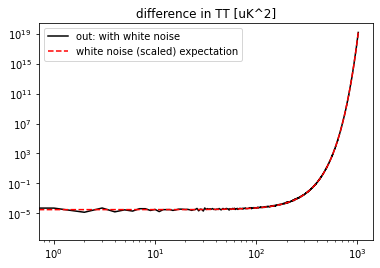

In [41]:
#focusing on white noise
lmin = 0
plt.loglog(Cl_wn_diff[0,lmin:lmax], color='black', label='out: with white noise')
plt.loglog(Nl_white_scaled[lmin:lmax], color='red', linestyle='dashed', label='white noise (scaled) expectation')
plt.title('difference in TT [uK^2]')
plt.legend()
plt.show()
#plt.savefig('TT_white.pdf')
plt.close() 

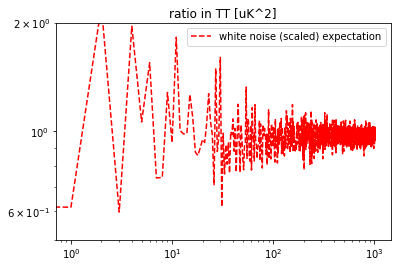

scaled white noise ratio: 1.5046572865585282


In [53]:
plt.loglog(Nl_white_scaled[lmin:lmax]/Cl_wn_diff[0,lmin:lmax], color='red', linestyle='dashed', label='white noise (scaled) expectation')
plt.title('ratio in TT [uK^2]')
plt.legend()
plt.ylim([0.5,2])
plt.show()
#plt.savefig('TT_white_ratio.pdf')
plt.close() 

print('scaled white noise ratio: '+str(np.mean(Nl_white_scaled[lmin:lmax]/Cl_wn_diff[0,lmin:lmax])))

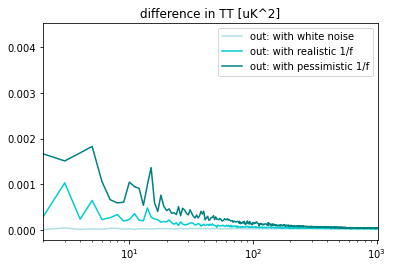

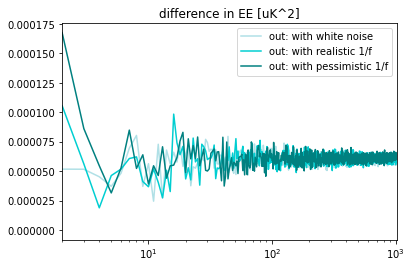

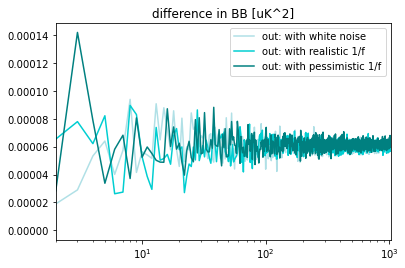

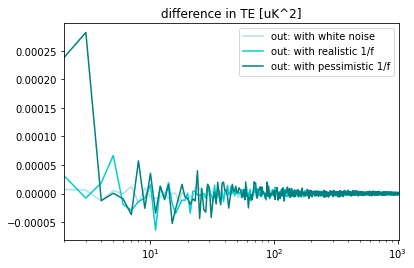

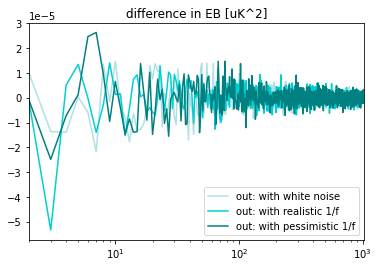

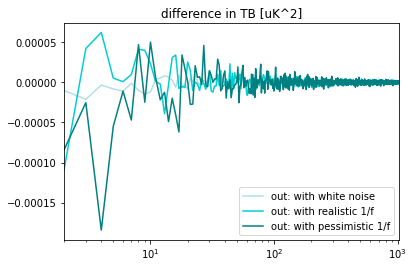

In [55]:
#plot all six diff spectra (only for low multipoles)
lmax_diff = lmax
arr = np.array(['TT','EE','BB','TE','EB','TB'])
for j in np.arange(6):
    plt.semilogx(Cl_wn_diff[j,:lmax_diff]*beam[j,:lmax_diff], color='powderblue', label='out: with white noise')
    plt.semilogx(Cl_wn_1f_30mHz[j,:lmax_diff]*beam[j,:lmax_diff], color='darkturquoise', label='out: with realistic 1/f')
    plt.semilogx(Cl_wn_1f_100mHz[j,:lmax_diff]*beam[j,:lmax_diff], color='teal', label='out: with pessimistic 1/f')
    #plt.semilogx(Cl_wn_1f_30mHz_destriped[j,:lmax_diff], color='black', label='out: with realistic 1/f, destriped with madam')        
    plt.title('difference in '+arr[j]+' [uK^2]')
    plt.xlim([2,lmax_diff])
    #plt.ylim([-0.0005,0.002]) #makes sense for TT only!
    plt.legend()
    plt.show()
    #plt.savefig(arr[j]+'_diff.pdf')
    plt.close()

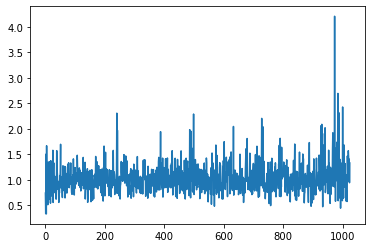

In [56]:
alpha_array = np.log((Cl_wn_1f_100mHz[0] - Cl_wn_diff[0])/(Cl_wn_1f_30mHz[0] - Cl_wn_diff[0]))/np.log(100/30)

plt.plot(alpha_array)
plt.show()
#plt.savefig('alpha.pdf')
plt.close()

In [57]:
present = time.time()-start
print('finished plotting ' + str(present) + ' seconds in')

finished plotting 562.0823540687561 seconds in
